# Lab 7: Byte Pair Encoding (BPE)

**Byte Pair Encoding (BPE)** is the subword tokenisation algorithm used in GPT-2, GPT-3, LLaMA, Mistral, and most modern large language models. In this lab we implement it from scratch, step by step.

---
## Why subword tokenisation?

There is a fundamental tension in how we cut text into tokens:

| Granularity | Vocab size | Sequence length | Unknown words |
|---|---|---|---|
| **Byte / character** | ~100–256 | Very long | None |
| **Subword (BPE)** | ~30k–100k | Medium | Rare |
| **Word** | ≥ 500k | Short | Common |

The `intro_transformer` notebook used *character-level* tokenisation: one token per character. This is conceptually simple but has two drawbacks:

1. **Long sequences.** A 1 000-word paragraph becomes ~5 000 characters. Since self-attention costs $O(n^2 d)$ this is expensive.
2. **Weak signal.** The model must learn from scratch, character by character, that `h e l l o` means "hello". Common substrings carry no pre-built meaning.

**BPE** finds a middle ground: it starts with characters and *iteratively merges the most frequent adjacent pair*, building up common syllables, morphemes, and whole words as single tokens — without ever hard-coding linguistic rules.

---
## BPE Algorithm — Big Picture

### Training  (learning the merges)
Given a corpus and a target vocabulary size $V$:

1. Initialise the vocabulary with every individual character that appears in the corpus.
2. Represent the corpus as a collection of word sequences (each word is a list of its current tokens).
3. Count every adjacent pair of tokens across the corpus (weighted by word frequency).
4. Select the most frequent pair $(a, b)$.
5. Create a new token $ab = a{+}b$ and add it to the vocabulary.
6. Replace every occurrence of the pair $(a, b)$ in the corpus with $ab$.
7. Repeat from step 3 until $|V| = V$ (or no pair appears more than once).

The output is an ordered list of **merge rules** — this is the trained BPE model.

### Encoding  (tokenising new text)
1. Split the text into individual characters.
2. Apply each merge rule **in the same order as it was learned**: wherever the pair $(a, b)$ occurs, replace it with $ab$.
3. The final sequence of strings is converted to integer IDs via the vocabulary lookup.

### Decoding
Simply concatenate all token strings: `''.join(vocab[id] for id in ids)`.

In [1]:
from collections import defaultdict
import re
import urllib.request
import matplotlib.pyplot as plt

---
## Exercise 1: Character-level Tokenisation

Before implementing BPE, let's review the simpler character-level tokenisation that served as our baseline in `intro_transformer.ipynb`. This is also the **starting point** for BPE — we always begin by splitting text into individual characters.

### Exercise 1.1 — Build the character vocabulary

Given a text string, build two dictionaries:

- `vocab : dict[int, str]` — maps an integer ID to the corresponding character string. IDs are assigned in sorted order, starting from 0.
- `token2id : dict[str, int]` — the inverse: maps a character string to its integer ID.

**Hint:** `sorted(set(text))` returns all unique characters in alphabetical order.

In [ ]:
def build_char_vocab(text: str) -> tuple[dict[int, str], dict[str, int]]:
    """
    Build a character-level vocabulary from `text`.

    Returns
    -------
    vocab    : int → str   (id to token string)
    token2id : str → int   (token string to id)
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Quick test ────────────────────────────────────────────────────────────────
sample_text = "hello world"
vocab_c, t2id_c = build_char_vocab(sample_text)
print("vocab    :", vocab_c)
print("token2id :", t2id_c)
print(f"Vocab size: {len(vocab_c)}")
# Expected: 8 unique characters: {' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w'}


### Exercise 1.2 — Character-level encode and decode

Using the two dictionaries from Exercise 1.1, implement:

- `char_encode(text, token2id) -> list[int]`: map each character to its integer ID.
- `char_decode(ids, vocab) -> str`: map each integer ID back to its string token and concatenate.

In [ ]:
def char_encode(text: str, token2id: dict[str, int]) -> list[int]:
    """Map each character in `text` to its integer ID."""
    # YOUR CODE HERE
    raise NotImplementedError


def char_decode(ids: list[int], vocab: dict[int, str]) -> str:
    """Reconstruct a string from a list of integer token IDs."""
    # YOUR CODE HERE
    raise NotImplementedError


# ── Quick test ────────────────────────────────────────────────────────────────
ids = char_encode("hello", t2id_c)
print("Encoded  :", ids)
print("Decoded  :", char_decode(ids, vocab_c))
assert char_decode(char_encode("hello world", t2id_c), vocab_c) == "hello world"
print("Roundtrip OK ✓")


---
## Exercise 2: Tokenisation with a Given BPE Vocabulary

A trained BPE model is fully described by two objects:

1. `vocab : dict[int, str]` — the full vocabulary. Initially it contains only individual characters; after training it also contains multi-character tokens such as `'er'`, `'he'`, `'the'`, …
2. `merges : list[tuple[str, str]]` — the **ordered** list of merge rules learned during training. *The order matters*: merges must be applied in exactly the same order during encoding as they were learned.

In this exercise we implement **encoding** and **decoding** *assuming these objects are already available*. In Exercise 3 we will see how to learn them.

---
### Exercise 2.1 — Apply a single merge rule

The core primitive of BPE encoding is applying one merge rule to a sequence of string tokens.

Implement:

```python
apply_merge(tokens: list[str], pair: tuple[str, str]) -> list[str]
```

- `tokens` is the current tokenisation: a list of strings.
- `pair = (a, b)`: wherever token `a` is **immediately followed** by token `b`, replace the two tokens with the single token `a + b`.
- Return the updated sequence.

**Example:**
```
tokens = ['h', 'e', 'l', 'l', 'o']
pair   = ('l', 'l')
result → ['h', 'e', 'll', 'o']
```

**Hint:** Walk through `tokens` with an index `i`.
- If `tokens[i] == a` and `tokens[i+1] == b`, append `a+b` and skip **two** positions (`i += 2`).
- Otherwise, append `tokens[i]` and advance by one (`i += 1`).

**Edge case — overlapping pairs:** If the sequence is `['a', 'a', 'a']` and the pair is `('a', 'a')`, the greedy left-to-right scan produces `['aa', 'a']` (not `['a', 'aa']`). This matches the original BPE paper.

In [ ]:
def apply_merge(tokens: list[str], pair: tuple[str, str]) -> list[str]:
    """
    Apply one BPE merge rule to a list of string tokens.

    Parameters
    ----------
    tokens : current tokenisation (list of strings)
    pair   : (a, b) — wherever a is immediately followed by b, replace with a+b

    Returns
    -------
    New list of string tokens with the merge applied.
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Tests ─────────────────────────────────────────────────────────────────────
print(apply_merge(['h', 'e', 'l', 'l', 'o'],   ('l', 'l')))
# → ['h', 'e', 'll', 'o']

print(apply_merge(['h', 'e', 'll', 'o', ' ', 'w', 'o', 'r', 'l', 'd'], ('o', ' ')))
# → ['h', 'e', 'll', 'o ', 'w', 'o', 'r', 'l', 'd']

print(apply_merge(['a', 'a', 'a'], ('a', 'a')))
# → ['aa', 'a']   (greedy left-to-right: first pair consumed, third 'a' left alone)

print(apply_merge(['h', 'e', 'l', 'l', 'o'], ('x', 'y')))
# → ['h', 'e', 'l', 'l', 'o']   (pair not present — unchanged)


### Exercise 2.2 — Encode a string given a list of merges

Now implement the full BPE encoding:

```python
encode(text: str, merges: list[tuple[str, str]], token2id: dict[str, int]) -> list[int]
```

**Algorithm:**
1. Split `text` into individual characters: `tokens = list(text)`.
2. For each merge rule `(a, b)` **in order**, call `tokens = apply_merge(tokens, (a, b))`.
3. After all merges, look up each token string in `token2id` to get an integer ID and return the list of IDs.

**Why the order matters:** Each merge may create *new, longer tokens* that become inputs to subsequent merges. For example, after learning `('e','r') → 'er'`, a later merge `('w','er') → 'wer'` only fires once `er` exists as a single token. If you applied the second merge first (before `er` has been created), nothing would happen.

This means the merge list is the complete "encoding recipe": you must store it and replay it in the same order at inference time.

In [ ]:
def encode(
    text:     str,
    merges:   list[tuple[str, str]],
    token2id: dict[str, int],
) -> list[int]:
    """
    BPE-encode a string (a single word, no spaces).

    Parameters
    ----------
    text     : the raw input word
    merges   : ordered list of (a, b) merge rules, as returned by bpe_train
    token2id : str → int vocabulary lookup

    Returns
    -------
    List of integer token IDs.
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test with a tiny hand-crafted vocabulary ──────────────────────────────────
#
# Suppose we trained BPE on "hello" with only two merge steps:
#   Step 1: ('l','l') → 'll'
#   Step 2: ('ll','o') → 'llo'
#
# Starting tokens: ['h','e','l','l','o']
# After step 1  : ['h','e','ll','o']
# After step 2  : ['h','e','llo']

small_merges   = [('l', 'l'), ('ll', 'o')]
small_vocab    = {0: 'h', 1: 'e', 2: 'l', 3: 'o', 4: 'll', 5: 'llo'}
small_token2id = {v: k for k, v in small_vocab.items()}

ids = encode("hello", small_merges, small_token2id)
print("IDs     :", ids)                           # [0, 1, 5]
print("Tokens  :", [small_vocab[i] for i in ids]) # ['h', 'e', 'llo']


### Exercise 2.3 — Decode

Implement:

```python
decode(ids: list[int], vocab: dict[int, str]) -> str
```

**Hint:** BPE decoding is trivially lossless — each token string is exactly the original bytes. Just concatenate.

Decoding does *not* need the merge list.

In [ ]:
def decode(ids: list[int], vocab: dict[int, str]) -> str:
    """
    BPE-decode a list of integer token IDs to a string.

    Parameters
    ----------
    ids   : list of integer token IDs
    vocab : int → str vocabulary

    Returns
    -------
    The original string (lossless).
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Roundtrip test ────────────────────────────────────────────────────────────
ids  = encode("hello", small_merges, small_token2id)
back = decode(ids, small_vocab)
print(f"'hello' → {ids} → '{back}'")
assert back == "hello", "Roundtrip failed!"
print("Roundtrip OK ✓")


**Summary of Exercise 2:** With only `apply_merge`, `encode`, and `decode` we can tokenise and detokenise *any* string, provided we have the trained `merges` list and `vocab` dictionary. The next step is to *learn* those objects.

---
## Exercise 3: BPE Training — Learning the Merge Rules

To select which pair to merge at each step, we need to count how often every adjacent pair of tokens appears across the entire training corpus.

### Corpus Representation

Iterating over the raw text character by character at each of hundreds of merge steps would be slow. Instead, we represent the corpus as a **word-frequency dictionary**:

```python
word_freqs : dict[tuple[str, ...], int]
```

Each key is a tuple of the current tokens for one distinct word (space-delimited unit), and the value is how many times that word appears in the corpus. When a merge is applied, we only need to update entries whose token tuple actually contains the merged pair.

**Example** on `"low lower lower newest newest newest"`:

```
{
  ('l','o','w')            : 1,
  ('l','o','w','e','r')    : 2,
  ('n','e','w','e','s','t'): 3,
}
```

### Exercise 3.1 — Build the word-frequency dictionary

Implement:

```python
build_word_freqs(text: str) -> dict[tuple[str, ...], int]
```

Split `text` on spaces (`text.split(' ')`). For each resulting word, represent it as a tuple of its individual characters. Count how many times each word-tuple appears.

**Hint:** Use `defaultdict(int)` and increment.

In [ ]:
def build_word_freqs(text: str) -> dict[tuple[str, ...], int]:
    """
    Split `text` on spaces and build a word-frequency dictionary.

    Each distinct word is stored as a tuple of its characters (the initial
    BPE tokens). The value is the word's frequency in the text.

    Returns
    -------
    word_freqs : { (char1, char2, ...) : frequency }
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
sample = "low lower lower newest newest newest"
wf = build_word_freqs(sample)
for word_tuple, freq in wf.items():
    print(f"  {''.join(word_tuple)!r:10s} → tokens={word_tuple}  freq={freq}")


### Exercise 3.2 — Count adjacent pairs

Implement:

```python
count_pairs(word_freqs: dict[tuple[str,...], int]) -> dict[tuple[str,str], int]
```

For each `(word_tuple, freq)` pair in `word_freqs`, and for each adjacent pair `(word_tuple[i], word_tuple[i+1])`, add `freq` to that pair's count.

**Key insight:** we weight every pair by the word's frequency. A pair `('e','r')` inside a word that appears 1000 times should count 1000 times, not 1.

**Example (from our sample above):**

| Pair  | From `low`(×1) | From `lower`(×2) | From `newest`(×3) | Total |
|-------|:--------------:|:----------------:|:-----------------:|------:|
| (l,o) | 1 | 2 | — | 3 |
| (o,w) | 1 | 2 | — | 3 |
| (w,e) | — | 2 | 3 | **5** |
| (e,r) | — | 2 | — | 2 |
| (n,e) | — | — | 3 | 3 |
| (e,w) | — | — | 3 | 3 |
| (e,s) | — | — | 3 | 3 |
| (s,t) | — | — | 3 | 3 |

→ Best pair: **(w, e)** with total count **5**.

In [ ]:
def count_pairs(
    word_freqs: dict[tuple[str, ...], int]
) -> dict[tuple[str, str], int]:
    """
    Count all adjacent token pairs in the corpus, weighted by word frequency.

    Returns
    -------
    pair_counts : { (token_a, token_b) : total_count }
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
wf     = build_word_freqs("low lower lower newest newest newest")
pairs  = count_pairs(wf)
print("Adjacent pair counts (sorted by frequency):")
for pair, cnt in sorted(pairs.items(), key=lambda x: -x[1]):
    print(f"  {pair}  →  {cnt}")
# Expected top pair: ('w', 'e') with count 5


### Exercise 3.3 — Select the best pair

Implement:

```python
best_pair(pair_counts: dict[tuple[str,str], int]) -> tuple[str, str]
```

Return the pair with the highest count.

**Tie-breaking:** Python's `max` with a `key` function breaks ties by the first element encountered in iteration order (insertion order in Python ≥ 3.7). For reproducibility this is sufficient; real implementations sometimes add a secondary lexicographic key.

In [ ]:
def best_pair(pair_counts: dict[tuple[str, str], int]) -> tuple[str, str]:
    """Return the most frequent adjacent pair."""
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test ──────────────────────────────────────────────────────────────────────
wf    = build_word_freqs("low lower lower newest newest newest")
pairs = count_pairs(wf)
bp    = best_pair(pairs)
print(f"Best pair: {bp}  (count = {pairs[bp]})")   # ('w', 'e'), count 5

# More clear-cut example:
wf2    = build_word_freqs("aaab aaab aaab d aaab ac")
pairs2 = count_pairs(wf2)
print("\nIn 'aaab aaab aaab d aaab ac':")
for pair, cnt in sorted(pairs2.items(), key=lambda x: -x[1]):
    print(f"  {pair}  →  {cnt}")
print(f"Best pair: {best_pair(pairs2)}")  # ('a','a') with count 3×3 = 9


### Exercise 3.4 — Apply a merge to the entire corpus

When we learn a new merge `(a, b)`, we must update `word_freqs`: every word that contains the pair `(a, b)` must have it replaced by `ab`.

Implement:

```python
merge_word_freqs(
    word_freqs: dict[tuple[str,...], int],
    pair:       tuple[str, str],
) -> dict[tuple[str,...], int]
```

For each `(tokens, freq)` in `word_freqs`:
- Apply `apply_merge(list(tokens), pair)` to produce `new_tokens`.
- Store `new_tokens` (as a tuple) → same `freq` in the new dictionary.

**Note:** It is possible (though rare) that two different old word-tuples map to the same new tuple after a merge, so use `defaultdict(int)` and add frequencies.

In [ ]:
def merge_word_freqs(
    word_freqs: dict[tuple[str, ...], int],
    pair:       tuple[str, str],
) -> dict[tuple[str, ...], int]:
    """
    Apply merge `pair` to every word in `word_freqs`.

    Returns a new word_freqs dict with the merge applied throughout.
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Step-by-step trace on the classic example ─────────────────────────────────
print("Classic example: 'low lower lower newest newest newest'")
print("-" * 55)
wf = build_word_freqs("low lower lower newest newest newest")

for step in range(4):
    pairs = count_pairs(wf)
    if not pairs:
        break
    pair = best_pair(pairs)
    new_token = pair[0] + pair[1]
    print(f"\nStep {step + 1}: merge {pair} → '{new_token}'  (count={pairs[pair]})")
    wf = merge_word_freqs(wf, pair)
    for tokens, freq in wf.items():
        print(f"  {''.join(tokens)!r:15s} → {tokens}  freq={freq}")


### Exercise 3.5 — Full BPE training loop

We now have all the building blocks. Assemble the complete training algorithm:

```python
bpe_train(text: str, num_merges: int, verbose: bool = True)
  -> (merges, vocab, token2id)
```

**Algorithm:**
1. Call `build_word_freqs(text)` to get the initial corpus.
2. Collect all distinct characters from the corpus → initial vocabulary (sorted, IDs starting at 0).
3. Repeat up to `num_merges` times:
   - a. Count pairs with `count_pairs`.
   - b. If no pairs remain, stop early.
   - c. Choose the best pair with `best_pair`.
   - d. Append it to the `merges` list.
   - e. Build the new token string: `new_token = a + b`.
   - f. Assign it the next available integer ID and add it to `vocab` and `token2id`.
   - g. Update the corpus with `merge_word_freqs`.
4. Return `merges`, `vocab`, `token2id`.

**Initial vocab:** iterate over all token tuples in `word_freqs` and collect all characters. `sorted(set(...))` ensures a deterministic order.

In [ ]:
def bpe_train(
    text:       str,
    num_merges: int,
    verbose:    bool = True,
) -> tuple[list[tuple[str, str]], dict[int, str], dict[str, int]]:
    """
    Train BPE on `text` for `num_merges` merge steps.

    Parameters
    ----------
    text       : training corpus as a plain string
    num_merges : number of merge operations to learn
    verbose    : if True, print progress every 10 steps

    Returns
    -------
    merges   : ordered list of (a, b) merge rules
    vocab    : int → str  (final vocabulary)
    token2id : str → int  (inverse vocabulary)
    """
    # YOUR CODE HERE
    raise NotImplementedError


# ── Test on classic BPE example ───────────────────────────────────────────────
print("=" * 60)
print("Classic example: 'low lower lower newest newest newest'")
print("=" * 60)
merges_ex, vocab_ex, t2id_ex = bpe_train(
    "low lower lower newest newest newest",
    num_merges=15,
)
print(f"\nLearned {len(merges_ex)} merge(s).")
print(f"Final vocabulary ({len(vocab_ex)} tokens):", list(vocab_ex.values()))


Let's verify that `encode` and `decode` are inverse of each other using the learned vocabulary.

In [12]:
for word in ["low", "lower", "newest"]:
    ids        = encode(word, merges_ex, t2id_ex)
    back       = decode(ids, vocab_ex)
    tokens_str = [vocab_ex[i] for i in ids]
    ok         = "✓" if back == word else "✗"
    print(f"{ok}  {word!r:10s}  →  ids={ids}  tokens={tokens_str}  →  {back!r}")

✓  'low'       →  ids=[16]  tokens=['low']  →  'low'
✓  'lower'     →  ids=[15]  tokens=['lower']  →  'lower'
✓  'newest'    →  ids=[13]  tokens=['newest']  →  'newest'


---
## Exercise 4: Handling Spaces — Encoding Full Sentences

Our `build_word_freqs` splits the training text on spaces. This means **merge rules are learned *within* words**, not across word boundaries. When encoding a full sentence, we must:

1. Split the sentence on spaces.
2. Encode each word individually with `encode()`.
3. Insert the space token between the encoded words.

We need the space character `' '` in the vocabulary too. After training, if it was not in the training text (it won't be, since we use it as a separator), we add it manually.

### Exercise 4 — `encode_text` and `decode_text`

Implement:

```python
encode_text(text, merges, vocab, token2id) -> list[int]
decode_text(ids, vocab) -> str
```

**Hint for `encode_text`:** split on `' '`, encode each non-empty word, and between consecutive words insert the ID for `' '`. Make sure `' '` is in `token2id`; add it to both dictionaries if it is missing.

In [ ]:
def encode_text(
    text:     str,
    merges:   list[tuple[str, str]],
    vocab:    dict[int, str],
    token2id: dict[str, int],
) -> list[int]:
    """
    Encode a full text string (may contain spaces).

    Words are encoded individually; space tokens are inserted between them.
    If the space character is not yet in the vocabulary, it is added in-place.
    """
    # YOUR CODE HERE
    raise NotImplementedError


def decode_text(ids: list[int], vocab: dict[int, str]) -> str:
    """Decode a list of token IDs to a string (spaces included)."""
    # YOUR CODE HERE
    raise NotImplementedError


# ── Roundtrip tests ───────────────────────────────────────────────────────────
merges_r, vocab_r, t2id_r = bpe_train(
    "low lower lowest newest newest newest",
    num_merges=8,
    verbose=False,
)

test_sentences = ["low", "lower", "newest", "low lower", "newest lowest"]
print("Roundtrip tests:")
for sentence in test_sentences:
    ids        = encode_text(sentence, merges_r, vocab_r, t2id_r)
    back       = decode_text(ids, vocab_r)
    ok         = "✓" if back == sentence else "✗"
    token_strs = [vocab_r[i] for i in ids]
    print(f"  {ok}  {sentence!r:20s} → {token_strs}")


---
## Exercise 5: BPE on a Real Corpus — Shakespeare

With the full implementation in hand, let's train BPE on the Shakespeare corpus (the same data used in `intro_transformer.ipynb`) and study the resulting tokenisation.

In [14]:
# ── Download Shakespeare (~1 MB) ──────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/karpathy/char-rnn"
       "/master/data/tinyshakespeare/input.txt")
with urllib.request.urlopen(URL) as response:
    full_text = response.read().decode("utf-8")

# Use first 50 000 chars for a fast demo (≈ 8 000 unique words)
raw_corpus = full_text[:50_000]
# Normalise all whitespace (newlines, tabs, multiple spaces) to a single space
corpus = re.sub(r'\s+', ' ', raw_corpus).strip()

n_chars  = len(corpus)
n_words  = len(corpus.split())
n_unique = len(set(corpus.split()))
print(f"Corpus  : {n_chars:,} chars,  {n_words:,} words,  {n_unique:,} unique word types")
print(f"Sample  : {corpus[:120]!r}")

Corpus  : 49,657 chars,  8,957 words,  3,038 unique word types
Sample  : 'First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rath'


### Train BPE with 300 merges

In [15]:
print("Training BPE (300 merges)…  This takes ~30–60 seconds.")
merges_shk, vocab_shk, t2id_shk = bpe_train(corpus, num_merges=300)
print(f"\nFinal vocabulary size: {len(vocab_shk)} tokens")

Training BPE (300 merges)…  This takes ~30–60 seconds.
  Step   1: merged ('t', 'h')         → 'th'         (freq=1064,  vocab=58)
  Step   2: merged ('o', 'u')         → 'ou'         (freq= 645,  vocab=59)
  Step   3: merged ('th', 'e')        → 'the'        (freq= 598,  vocab=60)
  Step   4: merged ('r', 'e')         → 're'         (freq= 473,  vocab=61)
  Step   5: merged ('i', 'n')         → 'in'         (freq= 449,  vocab=62)
  Step  10: merged ('e', 'r')         → 'er'         (freq= 328,  vocab=67)
  Step  20: merged ('i', 't')         → 'it'         (freq= 215,  vocab=77)
  Step  30: merged ('b', 'e')         → 'be'         (freq= 167,  vocab=87)
  Step  40: merged ('e', 'd')         → 'ed'         (freq= 113,  vocab=97)
  Step  50: merged ('no', 't')        → 'not'        (freq=  93,  vocab=107)
  Step  60: merged ('hi', 'm')        → 'him'        (freq=  83,  vocab=117)
  Step  70: merged ('a', 'l')         → 'al'         (freq=  69,  vocab=127)
  Step  80: merged ('e', 't') 

### Exercise 5.1 — Inspect the learned vocabulary

Print the **last 30 tokens** added to the vocabulary. These are the largest, most complex subwords that BPE learned.

**Question:** Do they look like common English subwords or whole words?

In [16]:
print("First 30 tokens  (characters, IDs 0–29):")
for i in range(30):
    print(f"  {i:4d} : {vocab_shk[i]!r}")

print(f"\nLast 30 tokens added by merges "
      f"(IDs {len(vocab_shk)-30}–{len(vocab_shk)-1}):")
for i in range(len(vocab_shk) - 30, len(vocab_shk)):
    print(f"  {i:4d} : {vocab_shk[i]!r}")

First 30 tokens  (characters, IDs 0–29):
     0 : '!'
     1 : "'"
     2 : ','
     3 : '-'
     4 : '.'
     5 : ':'
     6 : ';'
     7 : '?'
     8 : 'A'
     9 : 'B'
    10 : 'C'
    11 : 'D'
    12 : 'E'
    13 : 'F'
    14 : 'G'
    15 : 'H'
    16 : 'I'
    17 : 'J'
    18 : 'K'
    19 : 'L'
    20 : 'M'
    21 : 'N'
    22 : 'O'
    23 : 'P'
    24 : 'R'
    25 : 'S'
    26 : 'T'
    27 : 'U'
    28 : 'V'
    29 : 'W'

Last 30 tokens added by merges (IDs 327–356):
   327 : 'spe'
   328 : 'own'
   329 : 'Se'
   330 : 'gu'
   331 : 'very'
   332 : 'ort'
   333 : 'If'
   334 : "o'"
   335 : 'love'
   336 : 'where'
   337 : 'They'
   338 : 'sir'
   339 : 'there'
   340 : 'tion'
   341 : 'onour'
   342 : 'cou'
   343 : 'coun'
   344 : 'ci'
   345 : 'god'
   346 : 'did'
   347 : 'men'
   348 : 'which'
   349 : 'other'
   350 : 'had'
   351 : 's:'
   352 : 'ca'
   353 : 'from'
   354 : 'er,'
   355 : 'old'
   356 : 'fid'


In [ ]:
def show_tokenisation(
    sentence: str,
    merges:   list[tuple[str, str]],
    vocab:    dict[int, str],
    token2id: dict[str, int],
) -> None:
    """Print the BPE tokenisation and compression ratio for a sentence."""
    # YOUR CODE HERE
    raise NotImplementedError


test_lines = [
    "To be or not to be",
    "What light through yonder window breaks",
    "All the world is a stage",
    "Therefore since brevity is the soul of wit",
]

for line in test_lines:
    show_tokenisation(line, merges_shk, vocab_shk, t2id_shk)


### Exercise 5.3 — Compression ratio vs. number of merges

Plot the compression ratio on a held-out sentence as a function of the number of merges, from 0 (pure character-level) to 300.

**Hint:** You don't need to retrain from scratch for each number of merges. You already have `merges_shk` (300 rules). Re-use the **same merge list** but truncate it: use only the first `k` merges.

The initial character vocabulary `vocab_shk` and `t2id_shk` are unchanged — they contain all 300 merges, but `encode()` only applies the rules you pass it.

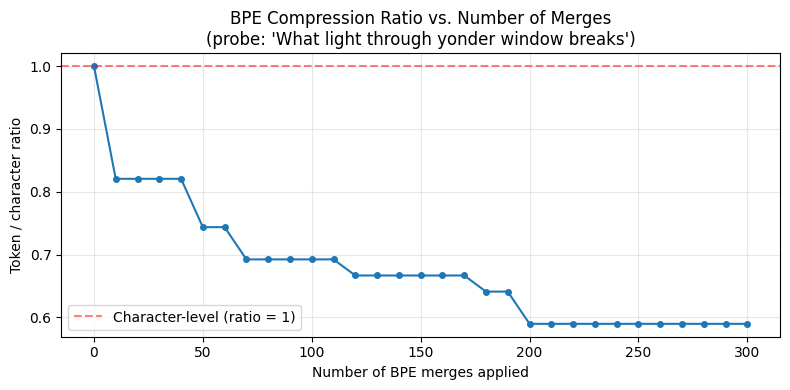

0 merges (char level): ratio = 1.000
300 merges            : ratio = 0.590
Improvement: 1.7× fewer tokens than char-level


In [18]:
probe_sentence = "What light through yonder window breaks"

merge_checkpoints = list(range(0, len(merges_shk) + 1, 10))
ratios = []

for k in merge_checkpoints:
    subset_merges = merges_shk[:k]
    n_tok = 0
    for word in probe_sentence.split(' '):
        if word:
            n_tok += len(encode(word, subset_merges, t2id_shk))
    n_tok += probe_sentence.count(' ')   # each space = 1 token
    ratios.append(n_tok / len(probe_sentence))

plt.figure(figsize=(8, 4))
plt.plot(merge_checkpoints, ratios, marker='o', markersize=4)
plt.axhline(1.0, color='r', linestyle='--', alpha=0.5, label='Character-level (ratio = 1)')
plt.xlabel("Number of BPE merges applied")
plt.ylabel("Token / character ratio")
plt.title("BPE Compression Ratio vs. Number of Merges\n"
          f"(probe: {probe_sentence!r})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"0 merges (char level): ratio = {ratios[0]:.3f}")
print(f"{len(merges_shk)} merges            : ratio = {ratios[-1]:.3f}")
print(f"Improvement: {ratios[0]/ratios[-1]:.1f}× fewer tokens than char-level")

### Exercise 5.4 — Roundtrip on Shakespeare sentences

Verify that `encode_text` followed by `decode_text` perfectly reconstructs the original text for sentences drawn from the corpus.

In [19]:
test_fragments = [
    "To be or not to be",
    "Friends Romans countrymen",
    "All that glitters is not gold",
]

print("Roundtrip tests on Shakespeare sentences:")
for frag in test_fragments:
    ids        = encode_text(frag, merges_shk, vocab_shk, t2id_shk)
    back       = decode_text(ids, vocab_shk)
    ok         = "✓" if back == frag else "✗"
    token_strs = [vocab_shk[i] for i in ids]
    print(f"  {ok}  {frag!r}")
    print(f"      tokens: {token_strs}")
    print()

Roundtrip tests on Shakespeare sentences:
  ✓  'To be or not to be'
      tokens: ['To', ' ', 'be', ' ', 'or', ' ', 'not', ' ', 'to', ' ', 'be']

  ✓  'Friends Romans countrymen'
      tokens: ['F', 'ri', 'end', 's', ' ', 'R', 'om', 'ans', ' ', 'coun', 't', 'ry', 'men']

  ✓  'All that glitters is not gold'
      tokens: ['A', 'll', ' ', 'that', ' ', 'g', 'l', 'it', 'ter', 's', ' ', 'is', ' ', 'not', ' ', 'go', 'ld']

